In [5]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 512
#L = 1. ## STILL BAD...
#L = N
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])


0.9999959147668984
0.9999981839783889
0.9999996628349158
0.9999988794792083
0.9999997910381101
0.9999997493159415
0.999999863386716
0.9999998658168758
0.9999999955303523
0.9999999890870841
0.9999999998687285
0.9999999979224807
0.9999999994337531
0.9999999997468518
0.9999999999336893
0.9999999999729855
0.9999999999932796
0.9999999999986485
0.9999999999996947
0.9999999999998026


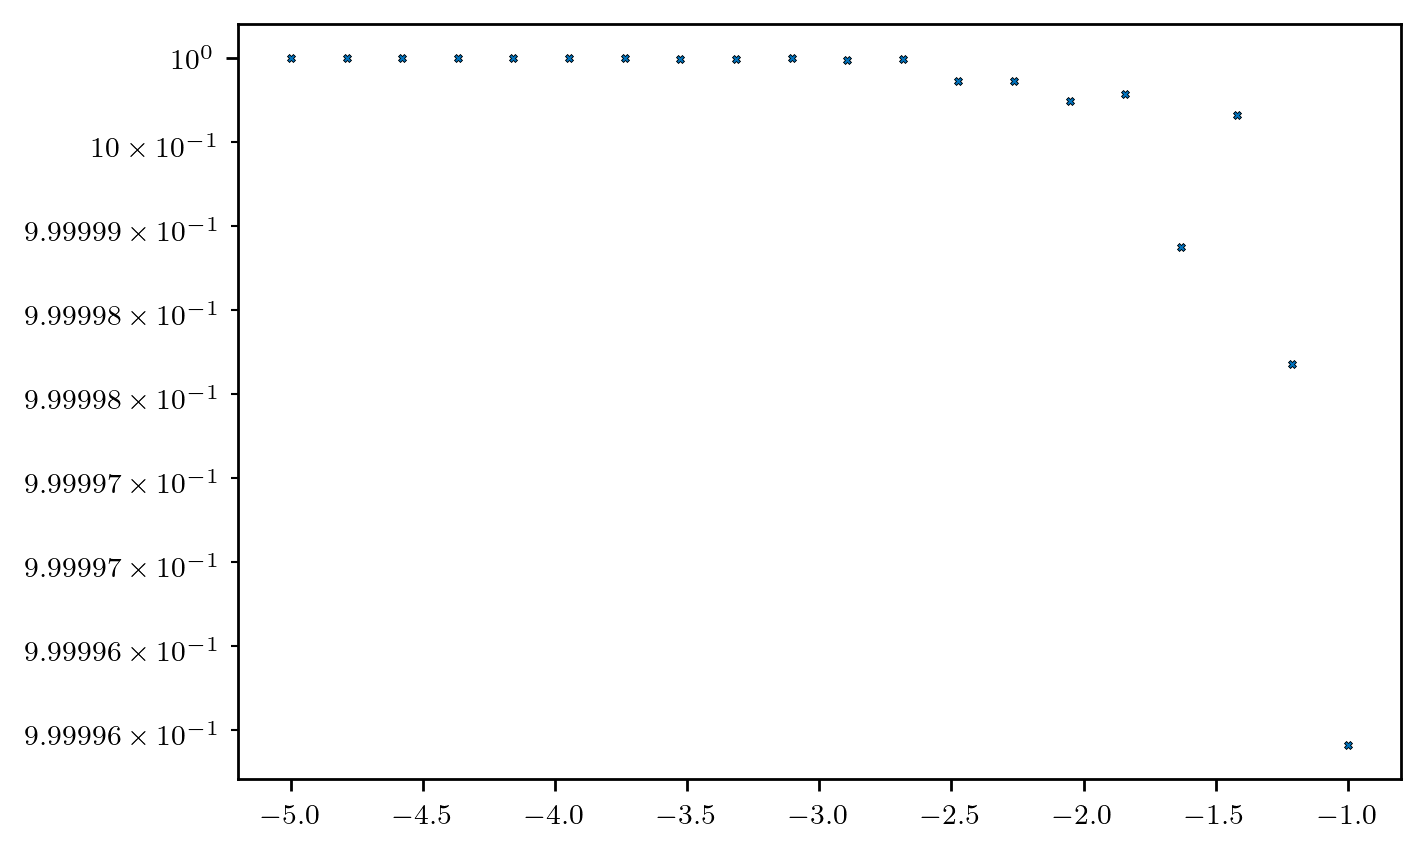

In [6]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))
    print(energies[-1])
specs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, lenn=phys_dims)
    #fekD = fekD / np.sum(np.ones_like(f) * dx**D)
    #fekD = fekD * (dk/twopi)**D
    specs.append((kD, fekD))
    e_parsevals = np.sum(fekD) * (dk/twopi)**D
    plt.scatter(alphas[i], e_parsevals, marker='X', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    plt.scatter(alphas[i], energies[i], marker='X', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    assert np.isclose(e_parsevals / energies[i], 1., rtol=0.001), e_parsevals / energies[i]

## TODO: TEST VIA AUTOCORRELATION FUNCTION TOO
plt.yscale('log')
#plt.ylim((9e-1, 1.1e0))

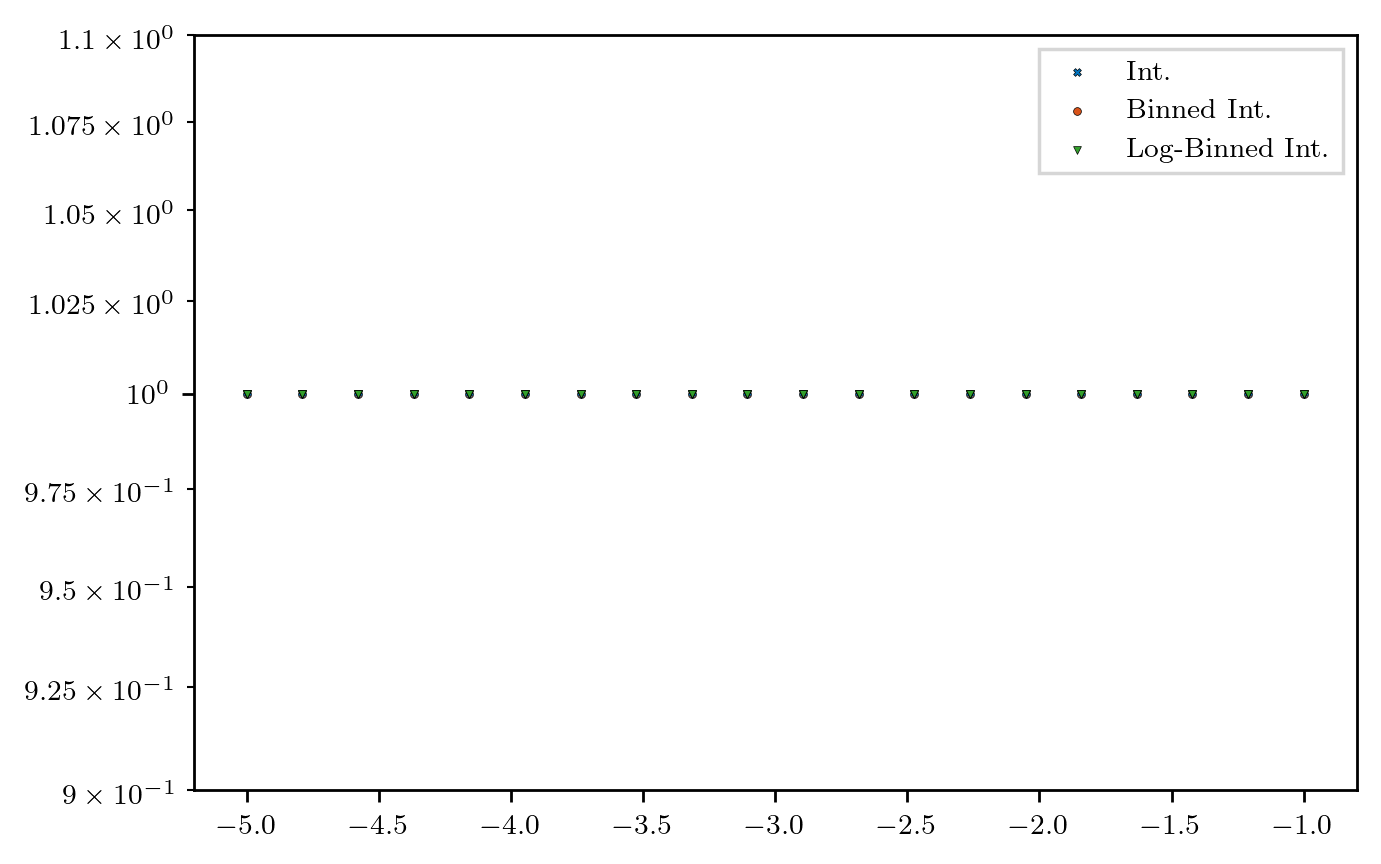

In [7]:
for e, kfek in enumerate(specs):
    kD, fekD = kfek
    ko, feko, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
        bin_func=np.nansum, min_bin=dk, max_bin=None,
        ignore_nan=False, norm_bin_size=True, bin_center=True,
        cut_excess=False, nan_small=False)
    e_estimation = np.nansum(feko * width) * (dk/twopi)**D
    #print(e_estimation / energies[e])
    plt.scatter(alphas[e], e_estimation / energies[e], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    #assert np.isclose(e_estimation / energies[e], 1., rtol=0.02), e_estimation / energies[e]

    for i in range(4, 8):
        ko, feko, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nansum, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_center=True,
            cut_excess=False, nan_small=False, num_bins=N//i)
        e_estimation = np.nansum(feko * width) * (dk/twopi)**D
        #print(e_estimation / energies[e])
        plt.scatter(alphas[e], e_estimation / energies[e], marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black', alpha=0.1)
        #assert np.isclose(e_estimation / energies[e], 1., rtol=0.02), e_estimation / energies[e]

    for i in range(4, 8):
        ko, feko, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nansum, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_center=True,
            cut_excess=False, nan_small=False, num_bins=N//i, log_space=True)
        e_estimation = np.nansum(feko * width) * (dk/twopi)**D
        #print(e_estimation / energies[e])
        plt.scatter(alphas[e], e_estimation / energies[e], marker='v', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')
        #assert np.isclose(e_estimation / energies[e], 1., rtol=0.02), e_estimation / energies[e]

plt.yscale('log')
plt.ylim((9e-1, 1.1e0))
plt.scatter([], [], marker='X', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'Int.')
plt.scatter([], [], marker='o', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Binned Int.')
plt.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Log-Binned Int.')
plt.legend(fancybox=False, frameon=True)

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/sc

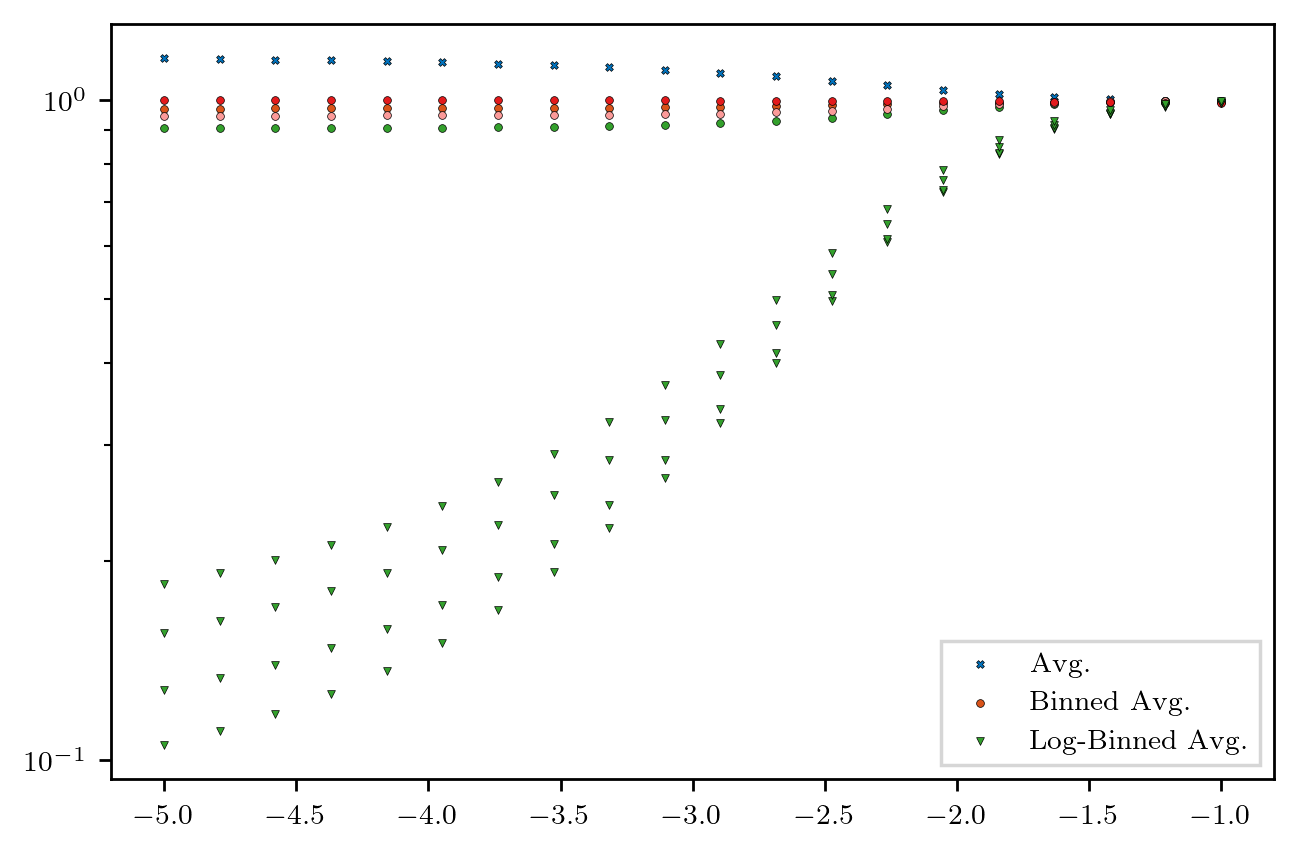

In [8]:

def kern(bins, D, _db, _dx):
    if D == 1:
        return 2.
    if D == 2:
        return (2. * np.pi * bins * _db + np.pi * _db**2) / _dx**2
    if D == 3:
        return (4./3.) * np.pi * (3. * bins * _db**2 + 3. * bins**2 * _db + _db**3) / _dx**3

def kern_center(bins, D, _db, _dx):
    if D == 1:
        return 2.
    if D == 2:
        return (2. * np.pi * bins * _db) / _dx**2
    if D == 3:
        return (4./3.) * np.pi * (3. * bins**2 * _db + _db**3 / 4.) / _dx**3

for e, kfek in enumerate(specs):
    kD, fekD = kfek
    km, fekm, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
        bin_func=np.nanmean, min_bin=dk, max_bin=None,
        ignore_nan=False, norm_bin_size=True, bin_center=True,
        cut_excess=True, nan_small=False)
    dOmega = kern_center(km, D, width, dk)
    e_estimation = np.nansum(fekm * dOmega * width) * (dk/twopi)**D
    #print(e_estimation / energies[e])
    plt.scatter(alphas[e], e_estimation / energies[e], marker='X', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    #assert np.isclose(np.nansum(fekm * width * dOmega) * (1./twopi)**D / energies[e], 1., rtol=0.001)

    for i in range(4, 8):
        km, fekm, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_center=True,
            cut_excess=True, nan_small=False, num_bins=N//i)
        dOmega = kern_center(km, D, width, dk)
        e_estimation = np.nansum(fekm * dOmega * width) * (dk/twopi)**D
        #print(e_estimation / energies[e])
        plt.scatter(alphas[e], e_estimation / energies[e], marker='o', s=5., color=c[i-4+1], zorder=2, linewidth=0.2, edgecolor='black')
        #assert np.isclose(np.nansum(fekm * width * dOmega) * (1./twopi)**D / energies[e], 1., rtol=0.001)

    for i in range(4, 8):
        km, fekm, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=True, bin_center=False,
            cut_excess=True, nan_small=False, num_bins=N//i, log_space=True)
        dOmega = kern(km, D, width, dk)
        e_estimation = np.nansum(fekm * dOmega * width) * (dk/twopi)**D
        #print(e_estimation / energies[e])
        plt.scatter(alphas[e], e_estimation / energies[e], marker='v', s=5., color=c[2], zorder=2, linewidth=0.2, edgecolor='black')
        #assert np.isclose(np.nansum(fekm * width * dOmega) * (1./twopi)**D / energies[e], 1., rtol=0.001)

plt.yscale('log')
#plt.ylim((9e-1, 1.1e0))
plt.scatter([], [], marker='X', s=5., color=c[0], linewidth=0.2, edgecolor='black', label=r'Avg.')
plt.scatter([], [], marker='o', s=5., color=c[1], linewidth=0.2, edgecolor='black', label=r'Binned Avg.')
plt.scatter([], [], marker='v', s=5., color=c[2], linewidth=0.2, edgecolor='black', label=r'Log-Binned Avg.')
plt.legend(fancybox=False, frameon=True)
